In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
import os
import gc
import sys
sys.path.append(os.path.abspath('..'))

plt.style.use('ggplot')

In [18]:
model = CatBoostClassifier()
model.load_model('../models/catboost_model.cbm')

feature_importance = model.get_feature_importance()
feature_name = model.feature_names_

importance_df = pd.DataFrame({
    'features': feature_name,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)
importance_df['importance'] = importance_df['importance'] / 100

print('Топ-10 самых важных признаков')
display(importance_df.head(10).round(4))

Топ-10 самых важных признаков


,features,importance
67,pre_util_min,0.1025
56,is_zero_loans530_mean,0.0492
139,enc_loans_credit_type_last,0.0435
68,pre_util_mean,0.0374
25,pre_loans_outstanding_min,0.0369
19,pre_loans_credit_limit_min,0.0314
59,is_zero_loans3060_mean,0.0293
130,enc_paym_23_nunique,0.0259
36,pre_loans_credit_cost_rate_max,0.0258
3,pre_since_opened_max,0.0246


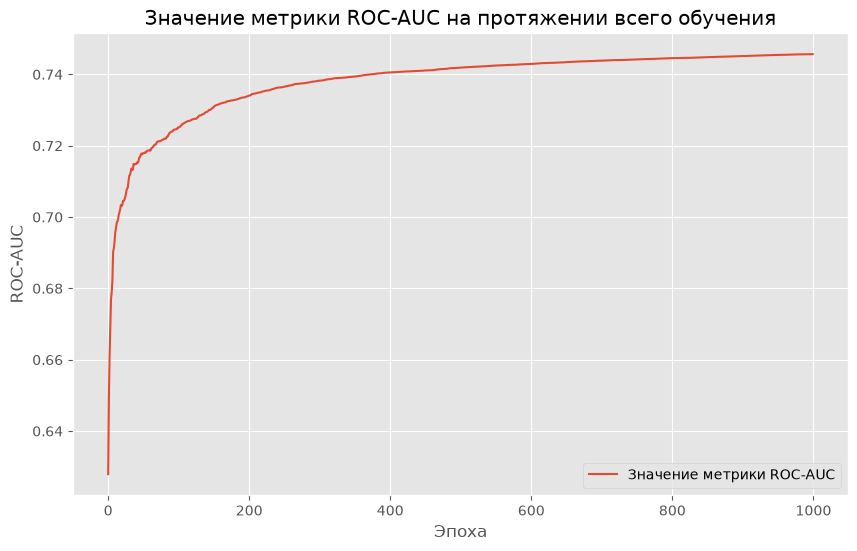

In [19]:
eval_result = model.get_evals_result()
val_auc_history = eval_result['validation']['AUC']

plt.figure(figsize=(10, 6))
sns.lineplot(data = val_auc_history, color='C0', label='Значение метрики ROC-AUC')
plt.legend(loc='lower right')
plt.title('Значение метрики ROC-AUC на протяжении всего обучения')
plt.xlabel('Эпоха')
plt.ylabel('ROC-AUC')
plt.show()

In [20]:
import pandas as pd
from pathlib import Path
from src.EDA.data_preprocessing import data_preprocessing, extract_features
from src.schema import category_cols, binary_cols

BASE_DIR = Path.cwd().parent
test_data_path = BASE_DIR / "datasets" / "train_data" / "train_data_11.pq"  # в качестве test dataset используем оставленный 11 датасет
target_data_path = BASE_DIR / "datasets" / "train_target.csv"

df_test = pd.read_parquet(test_data_path)
df_test = data_preprocessing(df_test, category_cols=category_cols, binary_cols=binary_cols)
df_test = extract_features(df_test, category_cols=category_cols, binary_cols=binary_cols)
df_target = pd.read_csv(target_data_path)
df_test = df_test.merge(df_target, on='id', how='left').set_index('id')

In [21]:
from catboost import Pool

X_test = df_test[model.feature_names_].copy()

cat_indices = model.get_cat_feature_indices()
cat_in_model = set(model.feature_names_[i] for i in cat_indices)

for col in X_test.select_dtypes(include=['category']).columns:
    if col not in cat_in_model:
        X_test[col] = X_test[col].astype(float)

test_pool = Pool(
    data=X_test,
    label=df_test['flag'] if 'flag' in df_test.columns else None,
    cat_features=cat_indices
)

pred = model.predict_proba(test_pool)

In [22]:
print(model.classes_)

[0 1]


В pred есть 2 колонки: принадлежность к классам model.classes_[0] и model.classes_[1], а надо искать вероятность принадлежности к классу 1, поэтому передаем pred[:, 1]

In [23]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

roc_auc = roc_auc_score(df_test['flag'], pred[:, 1]) # Возвращает вероятность того, что клиент уйдет в дефолт (т.е. вероятность класса 1)
print(f"ROC-AUC на тестовом датасете: {roc_auc:.4f}")

precision, recall, _ = precision_recall_curve(df_test['flag'], pred[:, 1])
pr_auc_score = auc(recall, precision)
print(f"Precision-Recall AUC на тестовом датасете: {pr_auc_score:.4f}")

ROC-AUC на тестовом датасете: 0.7172
Precision-Recall AUC на тестовом датасете: 0.0823


In [24]:
baseline_pr_auc = df_test['flag'].mean()
print(f"Базовый (случайный) PR-AUC: {baseline_pr_auc:.4f}")
print(f"Прирост модели: {pr_auc_score / baseline_pr_auc:.2f}x")

Базовый (случайный) PR-AUC: 0.0319
Прирост модели: 2.58x


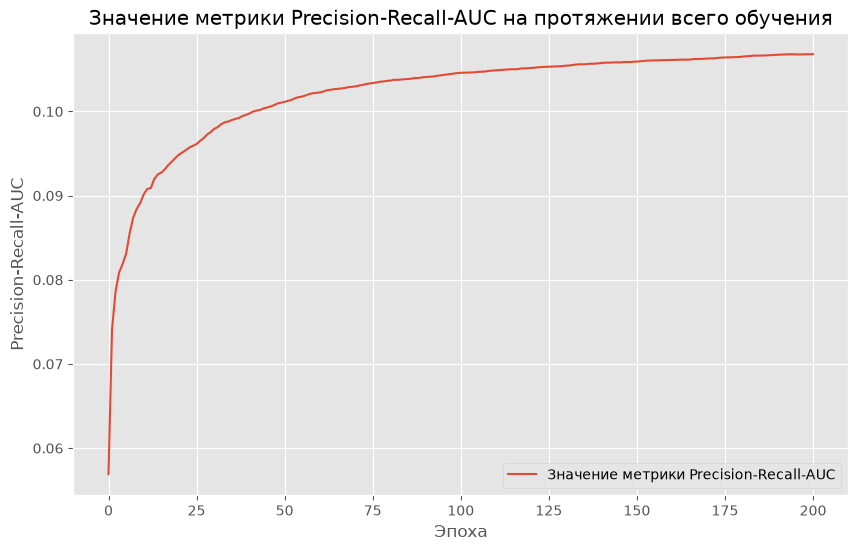

In [25]:
pr_auc_history = eval_result['validation']['PRAUC']

plt.figure(figsize=(10, 6))
sns.lineplot(data = pr_auc_history, color='C0', label='Значение метрики Precision-Recall-AUC')
plt.legend(loc='lower right')
plt.title('Значение метрики Precision-Recall-AUC на протяжении всего обучения')
plt.xlabel('Эпоха')
plt.ylabel('Precision-Recall-AUC')
plt.show()